In [31]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [32]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [33]:
file_path = r"C:\Users\HARSHITHA\Downloads\price_paid_records.csv.zip"
df = pd.read_csv(file_path, compression='zip', nrows=50000)

In [34]:
print("Dataset Loaded Successfully!")
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:\n", df.columns)

Dataset Loaded Successfully!
Shape of dataset: (50000, 11)

Columns in dataset:
 Index(['Transaction unique identifier', 'Price', 'Date of Transfer',
       'Property Type', 'Old/New', 'Duration', 'Town/City', 'District',
       'County', 'PPDCategory Type', 'Record Status - monthly file only'],
      dtype='object')


In [35]:
df.head()

,Transaction unique identifier,Price,Date of Transfer,Property Type,Old/New,Duration,Town/City,District,County,PPDCategory Type,Record Status - monthly file only
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A


In [36]:
df["Date of Transfer"] = pd.to_datetime(df["Date of Transfer"])

df["Year"] = df["Date of Transfer"].dt.year
df["Month"] = df["Date of Transfer"].dt.month

df = df.drop(columns=["Date of Transfer"])

df.head()

,Transaction unique identifier,Price,Property Type,Old/New,Duration,Town/City,District,County,PPDCategory Type,Record Status - monthly file only,Year,Month
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A,1995,8
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,S,N,F,GRAYS,THURROCK,THURROCK,A,A,1995,8
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,1995,6
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A,1995,11
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A,1995,6


In [37]:
cat_cols = ["Property Type", "Old/New", "Duration", "PPDCategory Type", "Record Status - monthly file only"]

print("Categorical columns to encode:")
print(cat_cols)

Categorical columns to encode:
['Property Type', 'Old/New', 'Duration', 'PPDCategory Type', 'Record Status - monthly file only']


In [38]:
encoder = OneHotEncoder(handle_unknown="ignore")

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, cat_cols)
    ],
    remainder="passthrough"
)

In [40]:
encoded_data = preprocessor.fit_transform(df)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", encoded_data.shape)

Shape before encoding: (50000, 12)
Shape after encoding: (50000, 17)


In [41]:
encoded_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)

print("Encoded categorical column names:")
print(encoded_feature_names)

Encoded categorical column names:
['Property Type_D' 'Property Type_F' 'Property Type_S' 'Property Type_T'
 'Old/New_N' 'Old/New_Y' 'Duration_F' 'Duration_L' 'PPDCategory Type_A'
 'Record Status - monthly file only_A']


In [42]:
# Combine encoded categorical column names 
# with remaining numeric columns

all_columns = list(encoded_feature_names) + \
              [col for col in df.columns if col not in cat_cols]

# Create DataFrame (NO .toarray() here)
encoded_df = pd.DataFrame(encoded_data, columns=all_columns)

# Display first 5 rowsa
encoded_df.head()

,Property Type_D,Property Type_F,Property Type_S,Property Type_T,Old/New_N,Old/New_Y,Duration_F,Duration_L,PPDCategory Type_A,Record Status - monthly file only_A,Transaction unique identifier,Price,Town/City,District,County,Year,Month
0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,OLDHAM,OLDHAM,GREATER MANCHESTER,1995,8
1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,GRAYS,THURROCK,THURROCK,1995,8
2,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,HIGHBRIDGE,SEDGEMOOR,SOMERSET,1995,6
3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,{1D861C06-A416-4865-973C-4956DB12CD12},43150,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,1995,11
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,WAKEFIELD,LEEDS,WEST YORKSHIRE,1995,6


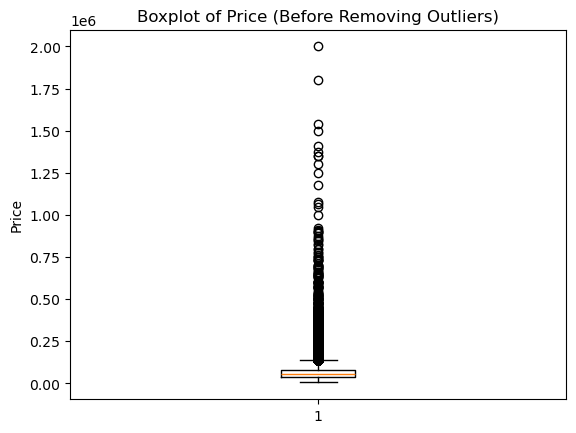

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(encoded_df["Price"])
plt.title("Boxplot of Price (Before Removing Outliers)")
plt.ylabel("Price")
plt.show()

In [17]:
encoded_df["Price"].describe()

count     50000
unique     2969
top       60000
freq        864
Name: Price, dtype: int64

In [18]:
Q1 = encoded_df["Price"].quantile(0.25)
Q3 = encoded_df["Price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 40000.0
Q3: 78950.0
IQR: 38950.0


In [19]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -18425.0
Upper Bound: 137375.0


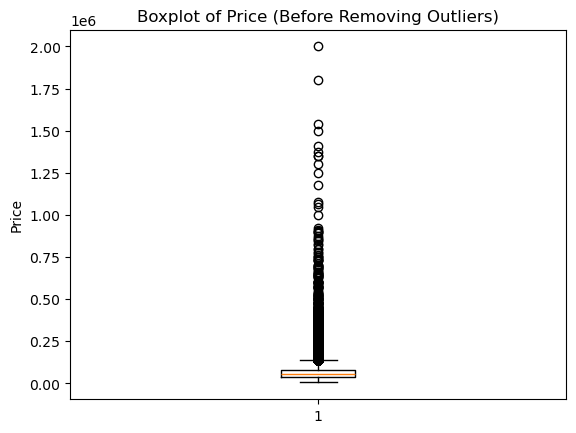

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(encoded_df["Price"])
plt.title("Boxplot of Price (Before Removing Outliers)")
plt.ylabel("Price")
plt.show()

In [21]:
#Removing outliers
cleaned_df = encoded_df[
    (encoded_df["Price"] >= lower_bound) &
    (encoded_df["Price"] <= upper_bound)
]

print("Original Shape:", encoded_df.shape)
print("After Removing Outliers:", cleaned_df.shape)

Original Shape: (50000, 17)
After Removing Outliers: (46654, 17)


In [22]:
print("Maximum Price Before:", encoded_df["Price"].max())
print("Maximum Price After:", cleaned_df["Price"].max())

Maximum Price Before: 2000000
Maximum Price After: 137250


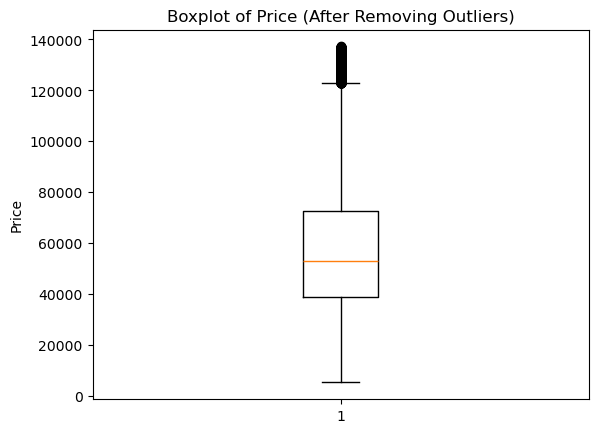

In [23]:
plt.figure()
plt.boxplot(cleaned_df["Price"])
plt.title("Boxplot of Price (After Removing Outliers)")
plt.ylabel("Price")
plt.show()

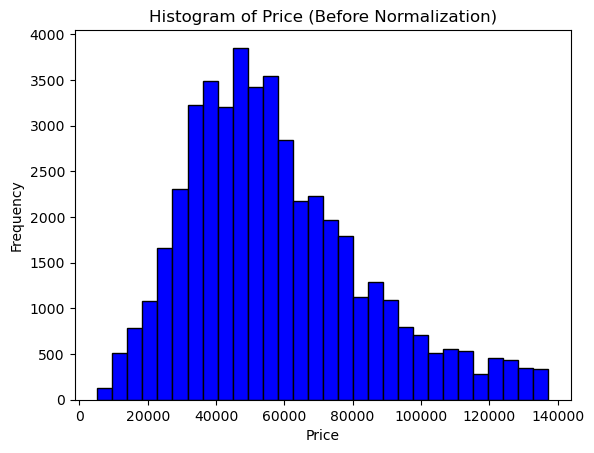

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(cleaned_df["Price"], bins=30, color="blue", edgecolor="black")
plt.title("Histogram of Price (Before Normalization)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

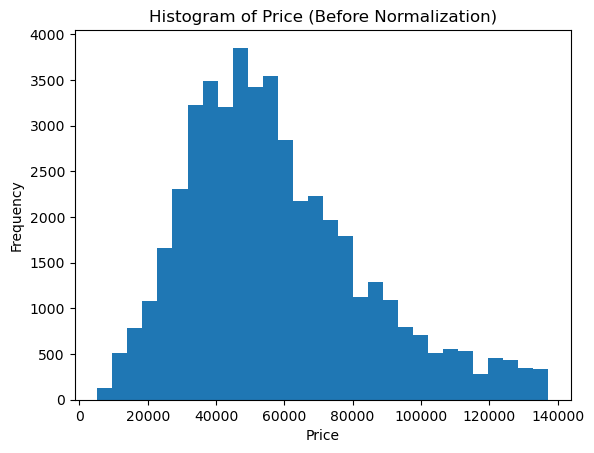

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(cleaned_df["Price"], bins=30)
plt.title("Histogram of Price (Before Normalization)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cleaned_df["Price_Normalized"] = scaler.fit_transform(
    cleaned_df[["Price"]]
)

cleaned_df[["Price", "Price_Normalized"]].head()

C:\Users\HARSHITHA\AppData\Local\Temp\ipykernel_12784\406790892.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["Price_Normalized"] = scaler.fit_transform(


,Price,Price_Normalized
0,25000,0.149621
1,42500,0.282197
2,45000,0.301136
3,43150,0.287121
4,18899,0.103402


In [27]:
print("Minimum Normalized Value:", cleaned_df["Price_Normalized"].min())
print("Maximum Normalized Value:", cleaned_df["Price_Normalized"].max())

Minimum Normalized Value: 0.0
Maximum Normalized Value: 1.0


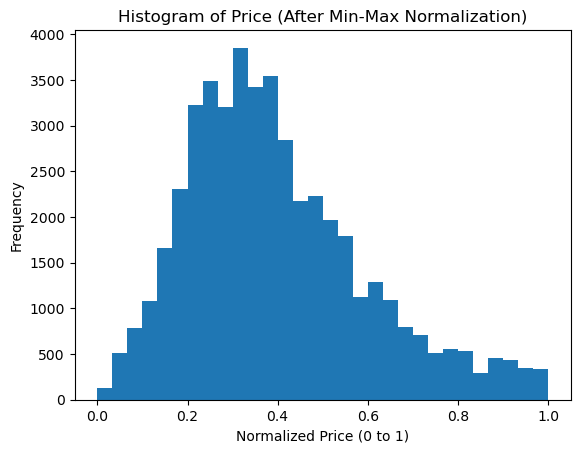

In [28]:
plt.figure()
plt.hist(cleaned_df["Price_Normalized"], bins=30)
plt.title("Histogram of Price (After Min-Max Normalization)")
plt.xlabel("Normalized Price (0 to 1)")
plt.ylabel("Frequency")
plt.show()

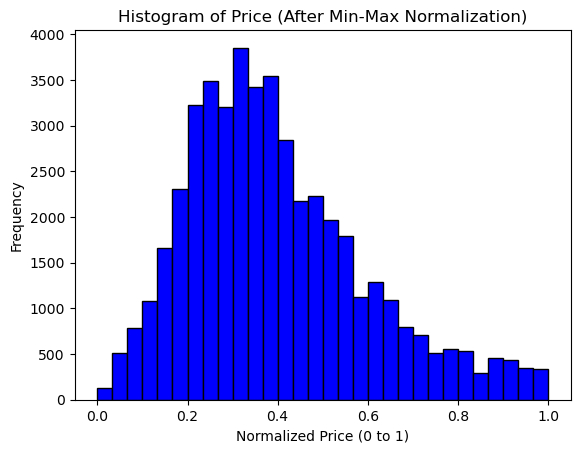

In [29]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(
    cleaned_df["Price_Normalized"], 
    bins=30, 
    color="blue", 
    edgecolor="black"
)

plt.title("Histogram of Price (After Min-Max Normalization)")
plt.xlabel("Normalized Price (0 to 1)")
plt.ylabel("Frequency")

plt.show()

In [30]:
df.head()

,Transaction unique identifier,Price,Property Type,Old/New,Duration,Town/City,District,County,PPDCategory Type,Record Status - monthly file only,Year,Month
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A,1995,8
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,S,N,F,GRAYS,THURROCK,THURROCK,A,A,1995,8
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,1995,6
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A,1995,11
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A,1995,6
